# 01-04 - The Walk Radius Duel

Here is a question a municipality actually asks: how many places to eat are within a four hundred metre walk of this door? Planners ask it about bus stops, about schools, about pharmacies. It is the simplest useful thing you can compute from the data we loaded in 01-02.

In this notebook we answer it twice. First we work it out together for Nassau Hall, getting it wrong twice on the way, because both wrong answers are instructive and one of them is genuinely dangerous. Then the same question is yours to answer for our own classroom, on the clock. Finally we hand it to an AI coding agent and grade what comes back against the number we computed ourselves.

We measure in a straight line today. Real walking follows streets and is always longer, and that is P07's business.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

## Getting our landmarks onto the map

The places to eat arrived as a spatial file, already carrying geometry. Our landmarks arrive as something plainer: a small table of coordinates in a `.csv` file, which is just text with commas in it.

Let us read it and look:

In [2]:
landmarks = pd.read_csv("data/landmarks.csv")
landmarks

,id,name,lat,lon
0,e225,Engineering Quad E225,40.35000,-74.65119
1,nassau_hall,Nassau Hall,40.34877,-74.65927
2,dinky,Princeton Station (Dinky),40.34362,-74.65950


Three rows and four columns. We have an `id` we can select on, a readable `name`, and the two numbers that place each landmark on the planet.

Note that this is a plain table, not a spatial one. It has no geometry column, and geopandas cannot draw it or measure anything from it. The latitude and longitude are sitting there as ordinary numbers, and we have to say explicitly that they are coordinates before anything spatial can happen.

That is what `points_from_xy` is for. It takes a column of x values and a column of y values and builds point geometry from them, and we hand the result to `gpd.GeoDataFrame` along with the CRS those numbers are in, which for latitude and longitude off a phone is always `EPSG:4326`:

In [3]:
places = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks["lon"], landmarks["lat"]),
    crs="EPSG:4326",
)
places

,id,name,lat,lon,geometry
0,e225,Engineering Quad E225,40.35000,-74.65119,POINT (-74.65119 40.35)
1,nassau_hall,Nassau Hall,40.34877,-74.65927,POINT (-74.65927 40.34877)
2,dinky,Princeton Station (Dinky),40.34362,-74.65950,POINT (-74.6595 40.34362)


The same three rows, now with a `geometry` column holding `POINT` values. This is a GeoDataFrame, and everything we did in 01-02 works on it.

Note the argument order, because it is the most common mistake in this entire subject. We wrote `points_from_xy(lon, lat)`, i.e. **x first, and x is longitude**. We say "latitude and longitude" out loud, in that order, and phone map applications show them in that order, so the temptation to type them that way is enormous. Doing so puts Princeton somewhere in Somalia, silently, with no error.

The rule to remember: in code, x comes first, and x is longitude, which for us is the negative one.

Let us pull out Nassau Hall, which we will use as the worked example:

In [4]:
nassau = places[places["id"] == "nassau_hall"]
food = gpd.read_file("data/princeton_food.geojson")

print(f"{len(nassau)} landmark, {len(food)} places to eat")

1 landmark, 92 places to eat


## The recipe, in words

We want the places to eat within four hundred metres of Nassau Hall. In words, the method has four steps:

1. Put both the landmark and the food into a coordinate system measured in metres.
2. Grow a circle of radius 400 around the landmark. That circle is called a **buffer**.
3. Ask, for every place to eat, whether it falls inside that circle.
4. Count the answers that came back true.

Step three deserves a note. Asking "is this point inside that shape" for every row at once gives us a column of True and False, exactly like the `== "cafe"` comparison in 01-02. And because Python counts True as one and False as zero, adding that column up *is* the count. So step four is a `.sum()`.

Now, step one looks like bureaucracy. It is not, and the next two cells are the reason.

## The first wrong answer, which is safe because it is absurd

Our data is in degrees. The number we want is 400. The obvious thing to do is to buffer by 400 and get on with our lives.

Let us do the obvious thing:

In [5]:
nassau_degrees = nassau.geometry.iloc[0]
circle = nassau_degrees.buffer(400)

print(f"places to eat inside: {int(food.within(circle).sum())} of {len(food)}")

places to eat inside: 92 of 92


Every single one. All 92, including places four kilometres away on the other side of the town.

Nothing raised an error, because nothing was wrong with the arithmetic. We asked for a circle of radius 400 in a system where one unit is a degree, and a degree is roughly 111 kilometres, so we drew a circle about 44,000 kilometres across. Let us look at where its edges are:

In [6]:
print(circle.bounds)

(-474.65927, -359.65123, 325.34073, 440.34877)


Longitude from about -474 to +325.

Longitude only runs from -180 to +180. There is no such place. Our circle is larger than the planet, which is why it caught everything, and this is the **safe** kind of wrong: it is so absurd that you cannot miss it. Any check at all catches it.

Note that the machine was perfectly happy. `buffer` has no way to know that you meant metres. It multiplies the number you gave it by the units the data happens to be in, and if you never told it what those units are, that is not its problem.

## The second wrong answer, which is dangerous because it is plausible

A reasonable person, having seen that, does some mental arithmetic. Four hundred metres is roughly four thousandths of a degree. So buffer by 0.004 and the units problem goes away.

Let us try that:

In [7]:
plausible = int(food.within(nassau_degrees.buffer(0.004)).sum())
print(f"places to eat inside: {plausible} of {len(food)}")

places to eat inside: 51 of 92


Fifty-one. That is a completely believable number. It is the right order of magnitude, it is less than the total, and if it appeared in a report nobody would blink.

It is also wrong, as we are about to see. And this is the dangerous kind of wrong: nothing about the output tells you. The absurd answer announced itself; this one does not.

It is wrong because a degree of longitude and a degree of latitude are not the same distance. A degree of latitude is about 111 kilometres everywhere. A degree of longitude is 111 kilometres at the equator and shrinks toward the poles, and at our latitude of about 40 degrees it is only around 85. So a circle of 0.004 degrees is not a circle on the ground at all, it is an ellipse, squashed east to west by about a quarter.

## The right answer

The fix is step one of the recipe, and it is one method call. We move both layers into `EPSG:26918`, a system measured in metres and designed for this strip of the world, and then `buffer(400)` really does mean four hundred metres:

In [8]:
metric = "EPSG:26918"

nassau_metres = nassau.to_crs(metric).geometry.iloc[0]
food_metres = food.to_crs(metric)

answer_nassau = int(food_metres.within(nassau_metres.buffer(400)).sum())
print(f"places to eat within 400 m of Nassau Hall: {answer_nassau}")

places to eat within 400 m of Nassau Hall: 55


Fifty-five.

So our plausible guess of 51 was wrong by four places, i.e. by about seven percent. Not catastrophic, and that is exactly what makes it dangerous. An error of seven percent survives review, gets copied into a slide, and becomes a number somebody plans a bus route around.

Let us look at what we actually asked for:

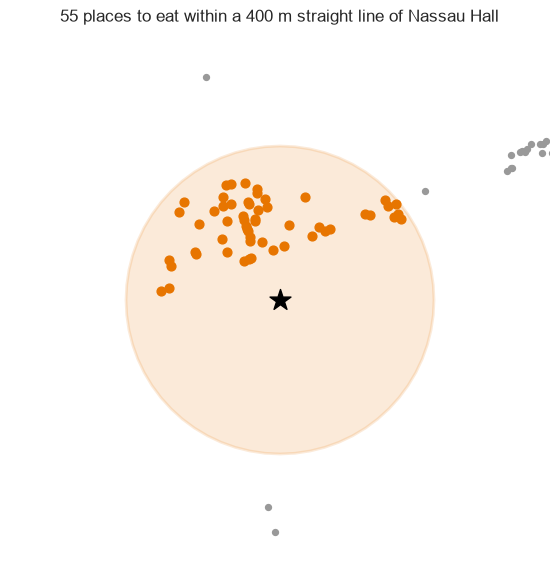

In [9]:
inside = food_metres[food_metres.within(nassau_metres.buffer(400))]

ax = gpd.GeoSeries([nassau_metres.buffer(400)], crs=metric).plot(
    figsize=(7, 7), color="#e77500", alpha=0.15, edgecolor="#e77500", linewidth=2)
food_metres.plot(ax=ax, color="#999999", markersize=18)
inside.plot(ax=ax, color="#e77500", markersize=40)
gpd.GeoSeries([nassau_metres], crs=metric).plot(ax=ax, color="black", marker="*", markersize=250)

bounds = nassau_metres.buffer(700).bounds
ax.set_xlim(bounds[0], bounds[2])
ax.set_ylim(bounds[1], bounds[3])
ax.set_title(f"{answer_nassau} places to eat within a 400 m straight line of Nassau Hall")
ax.set_axis_off()

The star is Nassau Hall, the shaded disc is our four hundred metre buffer, the orange dots are the 55 places inside it and the grey dots are the ones that missed.

Two things worth noticing. The circle really is a circle now, rather than the squashed ellipse the degree version would have drawn. And look at how many grey dots sit just outside the edge: the answer is sensitive to the radius we chose, which means four hundred metres is not a fact about Princeton, it is a decision we made. Extension notebook 01-09 takes that idea seriously.

## Now you, for our own classroom

Your turn, and there is a clock.

**How many places to eat are within a four hundred metre walk of E225, our classroom?**

Everything you need is above. The landmark you want has the id `e225` in the `places` table. The recipe has four steps, and you have seen each of them work. Write it in the cell below.

Most people will not finish inside five minutes, and that is fine and expected. The point is not speed, it is that you should feel the shape of this task in your own fingers before you hand it to a machine, because in twenty minutes that is exactly what you are going to do.

In [10]:
# Your attempt.
#
# The pieces you need, all of which appear above:
#   places[places["id"] == "e225"]   the landmark
#   food                             the places to eat
#   .to_crs(metric)                  step 1, into metres
#   .buffer(400)                     step 2, the circle
#   .within(...)                     step 3, inside or not
#   .sum()                           step 4, count the trues

## Handing the same question to an agent

Now we do it the way you will do everything else this semester.

A coding agent is a program that writes code for you. The one this course provides sits in the panel on the left of your editor, it can see the same files you can, and it can run them. That convenience is exactly why we spent this notebook learning to check things, because a tool that can run code quickly is a tool that can be wrong quickly.

The habit that makes it work is to **write the specification before you ask**. Not because the agent needs it, but because you do: if you cannot say what a correct answer would look like, you cannot recognise one when it arrives. Three lines are enough:

```text
PLACE:  which data, which file, which coordinate system
TASK:   what to compute, in what units
OUTPUT: what you want back, a number, a map, a table

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

The constraint about packages matters. Your environment is pinned so that everyone in the room has the same one, and an agent that installs something to solve a problem has quietly made your setup different from everybody else's.

Write your specification in the cell below, then give it to your agent.

```text
PLACE:

TASK:

OUTPUT:

Constraints: work only in this notebook, geopandas only, do not modify
earlier cells, do not install new packages.
```

In [11]:
# Paste what your agent gives you here, read it before you run it, then run it.

## The audit

The agent's work is not finished when it produces a number. It is finished when you have checked it.

**One, is the buffer computed in a coordinate system measured in metres?** You have now seen both ways this goes wrong: a buffer in degrees, which is absurd and safe, and a buffer in a guessed decimal, which is plausible and dangerous.

**Two, does the count match the number you computed yourself, and if it differs, can you say exactly why?** A different answer is not automatically a wrong one. An agent that counted bakeries as places to eat, or measured from the centre of the building rather than the door, has made a defensible choice and will get a defensible number. What is not acceptable is an answer you cannot account for.

**Three, is the circle actually on E225?** Draw it. The fastest way to catch a wrong landmark is to look at where the circle landed.

If your agent got everything right, say out loud what each of those checks would have caught. Verified work is the only kind that counts here, and an unverified right answer is luck rather than skill.

## Your first AI note

Every piece of work you hand in this semester carries three lines saying what you used, what it did, and what you checked. It is not a confession. It is the same professional habit as citing a source, and an accurate note makes the work your own.

Fill this in for what just happened, and keep it with your copy of this notebook:

```text
AI note
Tools:
They did:
Verified:
```

## Check your understanding

1. The degree buffer returned 92, i.e. the entire dataset. Why 92, and not an error?
2. Your agent returns the same number you did. Name one thing you have still not checked.
3. A classmate gets a different number and explains that they counted bakeries as places to eat. Is their answer wrong?
4. We measured in a straight line. For a question about walking, is our number too high or too low, and why?

## Where we are, and what is next

In three notebooks you have gone from never having run a line of Python to computing a real accessibility measure, getting it wrong in two instructive ways, and auditing a machine's answer against your own.

The extension notebooks in this folder take each piece apart properly and are yours to work through at your own pace. 01-05 opens up the GeoDataFrame, 01-06 explains coordinate systems in full, 01-07 takes the buffer seriously and shows why `within` and `intersects` give different answers, 01-08 is about reading a map honestly, and 01-09 asks our question nine times and finds something about Princeton that none of us expected.

## Further resources

Nothing in this course requires anything below.

**The operations we used.** Shapely is the library underneath geopandas that actually computes buffers and spatial relationships, and its manual explains each one with pictures: https://shapely.readthedocs.io/en/stable/manual.html. The geopandas guide to spatial relationships covers `within`, `intersects` and the rest: https://geopandas.org/en/stable/docs/user_guide/set_operations.html.

**Accessibility as a field.** The question we asked is a cumulative opportunities measure, one of the oldest ideas in transport planning. Levinson and Wu give a readable modern overview in "Towards a general theory of access", Journal of Transport Land Use, 2020, which is open access.

**The data.** The places to eat are an OpenStreetMap extract, snapshot 2026-08-29, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright.

---

## Appendix, break glass in case of emergency

Reference solutions. Try properly first, and if you do use these, treat them the way you would treat an agent's answer: read them, run them, and audit them.

<details>
<summary><b>The three checks from 01-03, solved</b></summary>

```python
import geopandas as gpd

mystery = gpd.read_file("data/mystery_boundary.geojson")

print(mystery.crs)
print(mystery.total_bounds)
print(mystery.to_crs("EPSG:26918").geometry.area.iloc[0] / 1e6)
```

</details>

<details>
<summary><b>The walk radius for E225, solved</b></summary>

```python
import geopandas as gpd
import pandas as pd

landmarks = pd.read_csv("data/landmarks.csv")
places = gpd.GeoDataFrame(
    landmarks,
    geometry=gpd.points_from_xy(landmarks["lon"], landmarks["lat"]),
    crs="EPSG:4326",
)
food = gpd.read_file("data/princeton_food.geojson")

e225 = places[places["id"] == "e225"].to_crs("EPSG:26918").geometry.iloc[0]
answer = int(food.to_crs("EPSG:26918").within(e225.buffer(400)).sum())
print(answer)
```

</details>